In [40]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import gc

In [41]:
data = pd.read_csv("../ecommerce_oct/product_price/csv/part-00000-f095e2c9-2f56-4429-bb68-84206dc6f974-c000.csv")
data.head()

,product_id,avg_price
0,6301113,45.723682
1,1004739,192.230384
2,21408554,259.356637
3,17800204,29.559027
4,1004666,1120.127494


## 2.3 Analysis for mean price of products

--- Price Distribution Statistics ---
count       165647.000000
mean           172.263711
std            291.818227
min              0.770000
25%             23.473182
50%             68.990000
75%            182.752143
max           2574.070000
skew             3.745944
kurtosis        17.842505
Name: avg_price, dtype: float64
----------------------------------------


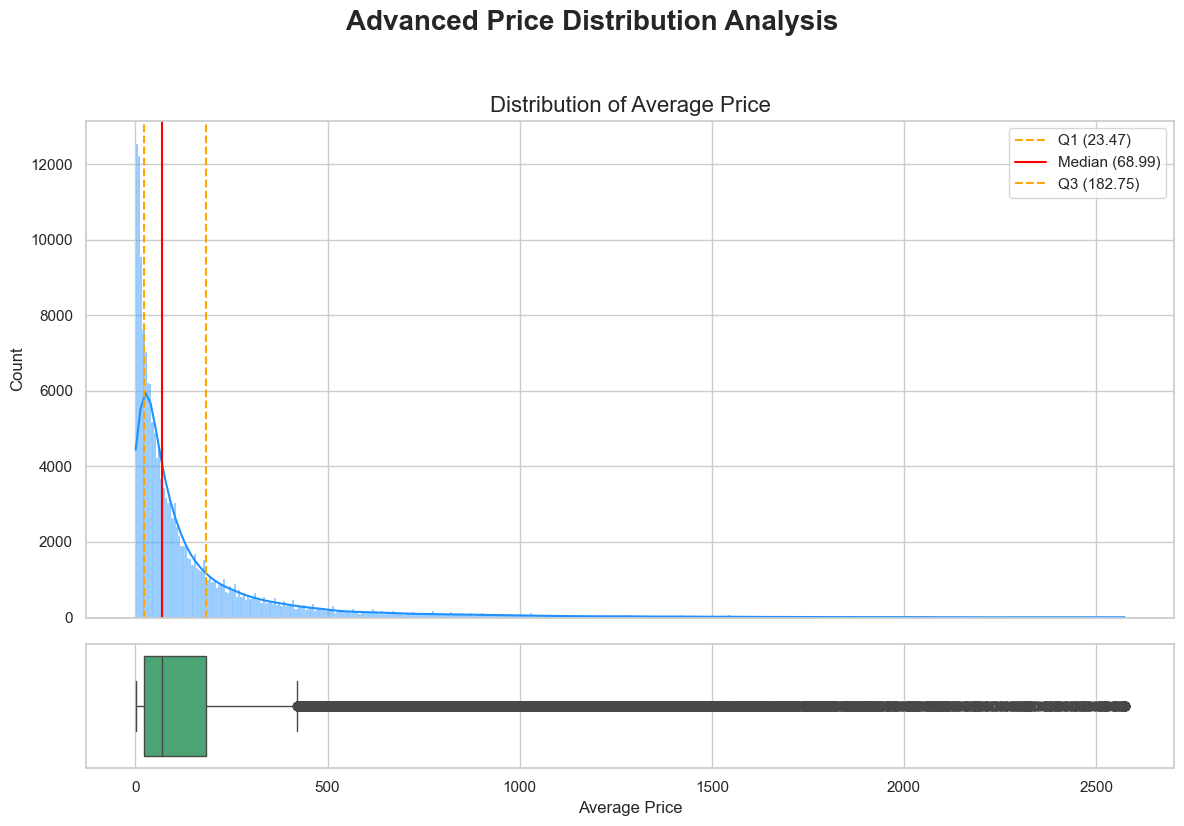

Fancy plot saved as 'fancy_price_distribution.png'


In [42]:
avg_price_series = data['avg_price']

# --- 2. Calculate Statistics (Still useful to see) ---
price_desc = avg_price_series.describe()
price_desc['skew'] = avg_price_series.skew()
price_desc['kurtosis'] = avg_price_series.kurtosis()

print("--- Price Distribution Statistics ---")
print(price_desc)
print("-" * 40)

# --- 3. Create the "Fancy" Hybrid Plot ---

# Set a modern Seaborn style
sns.set_theme(style="whitegrid")

# Create a figure with two subplots, stacked vertically
# Share the X-axis so they align
# 'height_ratios' makes the top plot 80% and bottom 20%
fig, axs = plt.subplots(
    2, 1, 
    figsize=(12, 8), 
    sharex=True, 
    gridspec_kw={'height_ratios': [0.8, 0.2]}
)

# --- Plot 1: The Histogram (Top) ---
# We use a distinct color for the main plot
sns.histplot(x=avg_price_series, kde=True, ax=axs[0], color="dodgerblue")

# Add vertical lines for quartiles and median
q1 = avg_price_series.quantile(0.25)
median = avg_price_series.median()
q3 = avg_price_series.quantile(0.75)

axs[0].axvline(q1, color='orange', linestyle='--', label=f'Q1 ({q1:.2f})')
axs[0].axvline(median, color='red', linestyle='-', label=f'Median ({median:.2f})')
axs[0].axvline(q3, color='orange', linestyle='--', label=f'Q3 ({q3:.2f})')

axs[0].legend()
axs[0].set_title('Distribution of Average Price', fontsize=16)
axs[0].set_xlabel('') # Remove x-label from top plot

# --- Plot 2: The Box Plot (Bottom) ---
# Use a different color for contrast
sns.boxplot(x=avg_price_series, ax=axs[1], color="mediumseagreen")
axs[1].set_xlabel('Average Price', fontsize=12)

# Add a main title for the entire figure
fig.suptitle('Advanced Price Distribution Analysis', fontsize=20, fontweight='bold', y=1.03)

# Clean up layout
plt.tight_layout()

# Save the plot
plot_filename = 'fancy_price_distribution.png'
plt.show()
plt.savefig(plot_filename, dpi=150, bbox_inches='tight')
print(f"Fancy plot saved as '{plot_filename}'")

# --- 4. Clean Up Memory ---
plt.close()
del fig

## 2.4 Top 10 product category Analysis

Top 10 Categories:
                                     count
category_code                             
unknown                           13475214
electronics.smartphone            11483829
electronics.clocks                 1307549
computers.notebook                 1135546
electronics.video.tv               1111485
electronics.audio.headphone        1098007
appliances.kitchen.refrigerators    886835
appliances.kitchen.washer           867739
appliances.environment.vacuum       800423
apparel.shoes                       761890
------------------------------
Generating bar plot...


/var/folders/_v/rp655h2s5z783x_7mbfhjbt40000gn/T/ipykernel_17725/3852562486.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  bars = sns.barplot(


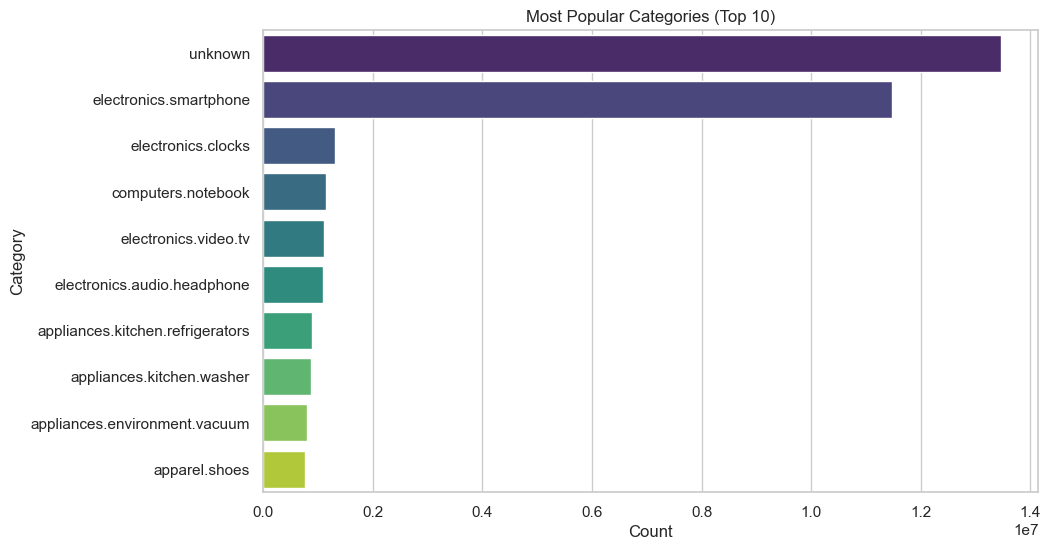

4606

In [47]:
CSV_FILE_NAME = '../ecommerce_oct/top10_categories/csv/part-00000-193d6b27-f5c6-4de9-a8b5-0d1caf010ee1-c000.csv' 

data = pd.read_csv(CSV_FILE_NAME)

# Check for required columns
if 'category_code' not in data.columns or 'count' not in data.columns:
    print(f"Error: CSV must have 'category_code' and 'count' columns.")
    print(f"Found columns: {data.columns.tolist()}")
else:
# Set category_code as the index for easier plotting
    data = data.set_index('category_code')

# Sort by count (descending) and get the top 10
top_10_categories = data.sort_values(by='count', ascending=False).head(10)

print("Top 10 Categories:")
print(top_10_categories)
print("-" * 30)

# --- 2. Create the Bar Plot ---
print("Generating bar plot...")
plt.figure(figsize=(10, 6))

# Plot using the 'count' column for x and the index (category_code) for y
bars = sns.barplot(
    x=top_10_categories['count'], 
    y=top_10_categories.index, 
    palette='viridis', 
)

# Add data labels to the bars

plt.title('Most Popular Categories (Top 10)')
plt.xlabel('Count')
plt.ylabel('Category')
plt.savefig('top_10_categories_bar.png', bbox_inches='tight')
plt.show()

# Clean up bar plot
del bars
plt.close()
gc.collect()

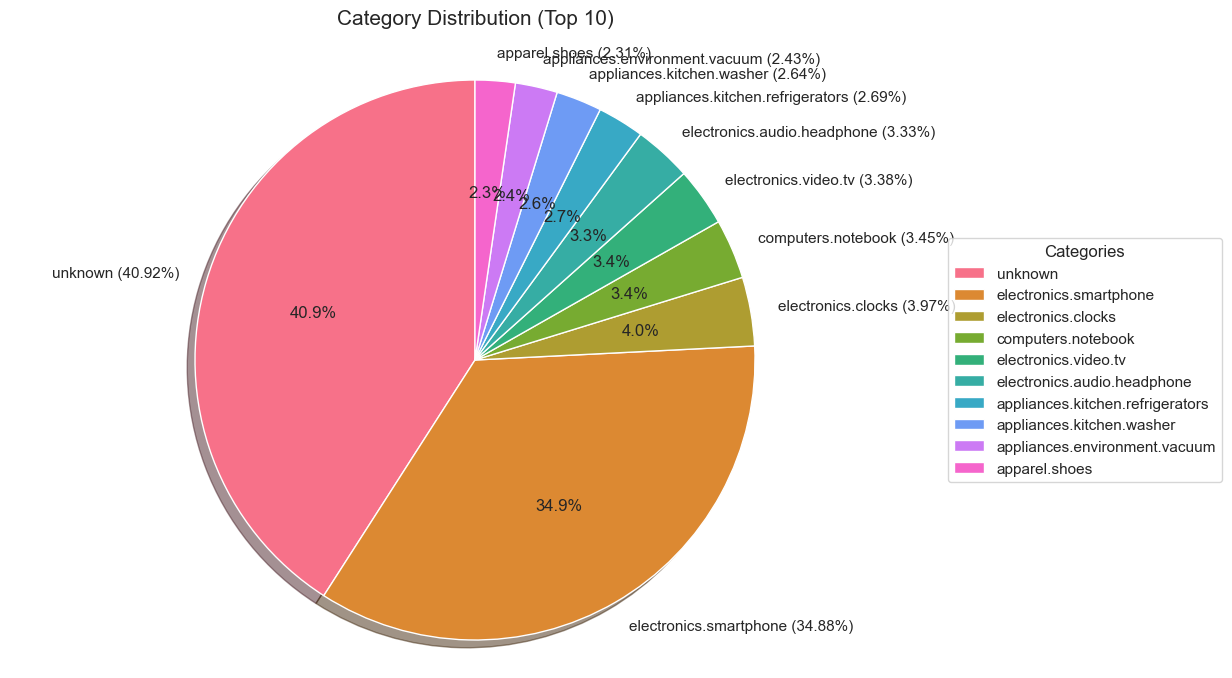


Category Percentages:
--------------------------------------------------
unknown                        :  40.92%
electronics.smartphone         :  34.88%
electronics.clocks             :   3.97%
computers.notebook             :   3.45%
electronics.video.tv           :   3.38%
electronics.audio.headphone    :   3.33%
appliances.kitchen.refrigerators :   2.69%
appliances.kitchen.washer      :   2.64%
appliances.environment.vacuum  :   2.43%
apparel.shoes                  :   2.31%


4722

In [44]:
# Calculate percentages
total_count = top_10_categories['count'].sum()
top_10_categories['percentage'] = (top_10_categories['count'] / total_count * 100).round(2)

# Create a pie chart
plt.figure(figsize=(12, 8))

# Use a colorful palette
colors = sns.color_palette('husl', n_colors=len(top_10_categories))

# Create pie chart
plt.pie(
    top_10_categories['percentage'],
    labels=[f"{idx} ({row['percentage']}%)" for idx, row in top_10_categories.iterrows()],
    colors=colors,
    autopct='%1.1f%%',
    startangle=90,
    shadow=True
)

# Add a title
plt.title('Category Distribution (Top 10)', pad=20, size=15)

# Add a legend
plt.legend(
    top_10_categories.index,
    title="Categories",
    loc="center left",
    bbox_to_anchor=(1, 0, 0.5, 1)
)

# Ensure the pie chart is circular
plt.axis('equal')

# Save and display the plot
plt.savefig('category_distribution_pie.png', bbox_inches='tight', dpi=150)
plt.show()

# Display the percentages in a table
print("\nCategory Percentages:")
print("-" * 50)
for idx, row in top_10_categories.iterrows():
    print(f"{idx:<30} : {row['percentage']:>6.2f}%")

# Clean up
plt.close()
gc.collect()

## Top 10 purchased product analisys

Loading data from '../ecommerce_oct/top10_categories_purchase/csv/part-00000-d7181a46-de31-42f5-81e1-e2f2b87dcc45-c000.csv'...

--- Top 10 Categories (Summary Table) ---


,count,percentage
category_code,,
electronics.smartphone,"337,979",52.62%
unknown,"173,411",27.00%
electronics.audio.headphone,"30,501",4.75%
electronics.video.tv,"21,561",3.36%
electronics.clocks,"17,903",2.79%
appliances.kitchen.washer,"16,146",2.51%
computers.notebook,"15,588",2.43%
appliances.environment.vacuum,"12,378",1.93%
appliances.kitchen.refrigerators,"11,218",1.75%



--- Descriptive Statistics for 'count' ---
count        10.000000
mean      64228.700000
std      108309.097457
min        5602.000000
25%       13180.500000
50%       17024.500000
75%       28266.000000
max      337979.000000
Name: count, dtype: float64

Generating bar plot...


/var/folders/_v/rp655h2s5z783x_7mbfhjbt40000gn/T/ipykernel_17725/1476579283.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  bars = sns.barplot(


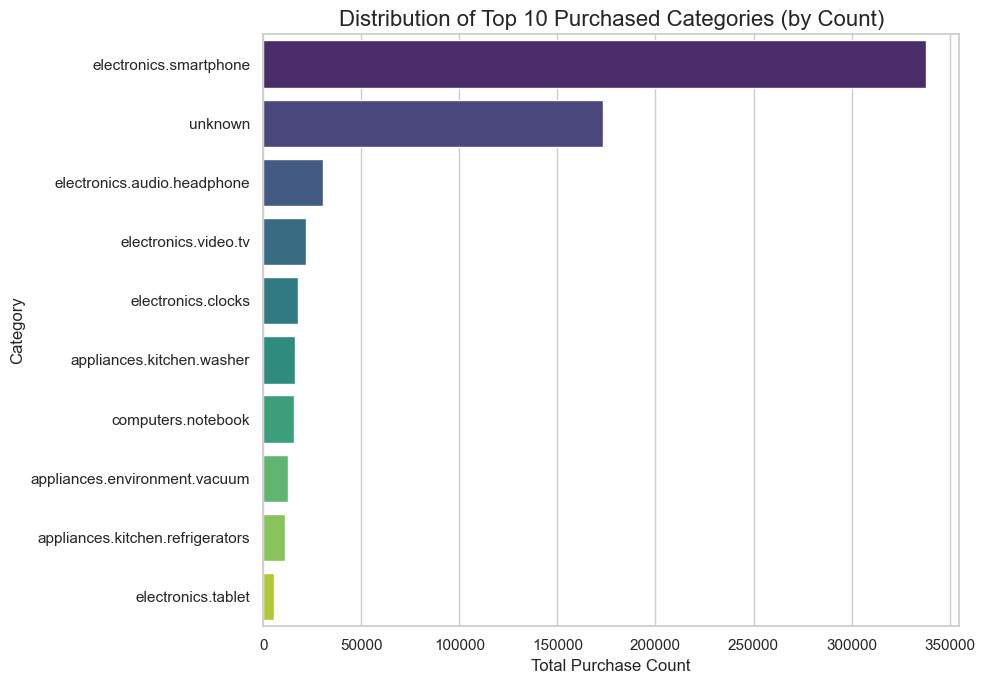

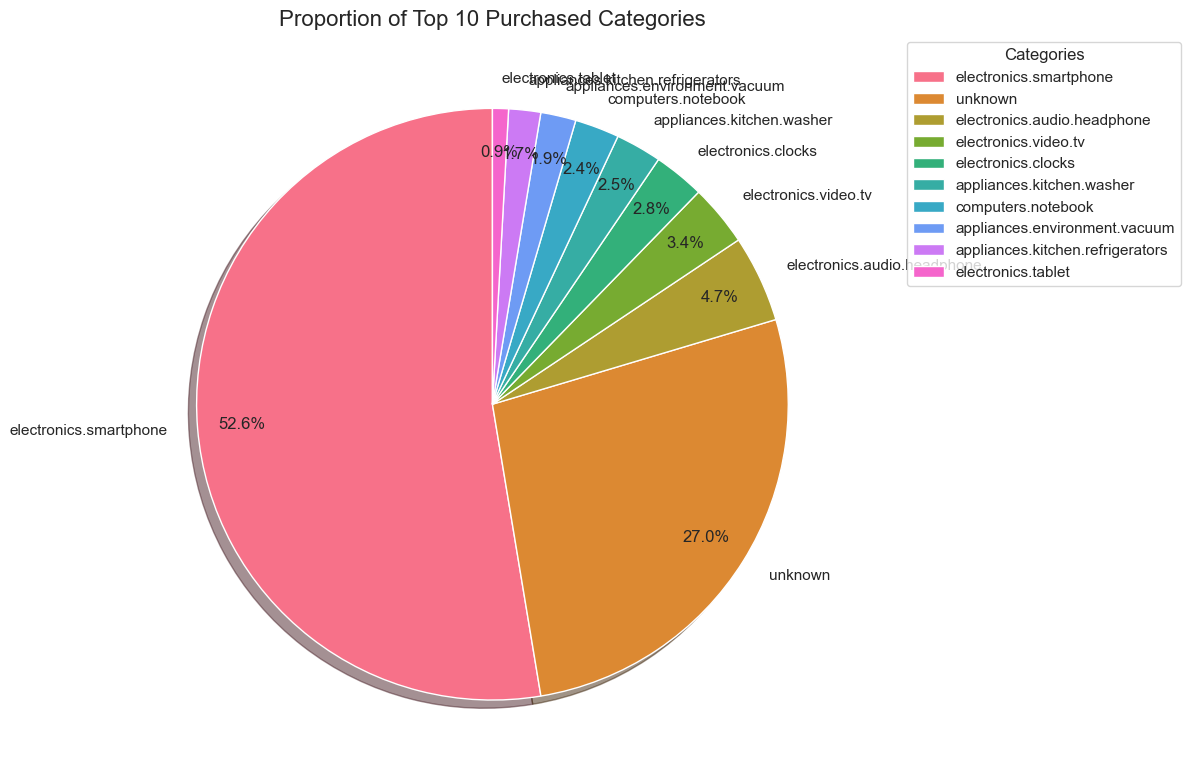

9166

In [45]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import gc

# --- Configuration ---
FILE_NAME = '../ecommerce_oct/top10_categories_purchase/csv/part-00000-d7181a46-de31-42f5-81e1-e2f2b87dcc45-c000.csv'

print(f"Loading data from '{FILE_NAME}'...")
data = pd.read_csv(FILE_NAME)

data = data.sort_values(by='count', ascending=False)

data['percentage'] = (data['count'] / data['count'].sum())

print("\n--- Top 10 Categories (Summary Table) ---")

styled_table = data.set_index('category_code').style.format({
    'count': '{:,.0f}',       # Format count with a comma
    'percentage': '{:.2%}'  # Format as percentage
})
display(styled_table)
print("\n--- Descriptive Statistics for 'count' ---")
count_stats = data['count'].describe()
print(count_stats)

print("\nGenerating bar plot...")
plt.figure(figsize=(10, 7))


bars = sns.barplot(
    x='count',
    y='category_code',
    data=data,
    palette='viridis' 
)


plt.title('Distribution of Top 10 Purchased Categories (by Count)', fontsize=16)
plt.xlabel('Total Purchase Count', fontsize=12)
plt.ylabel('Category', fontsize=12)
plt.tight_layout()
plt.savefig('top10_categories_bar.png')
plt.show()


plt.figure(figsize=(12, 8))


colors = sns.color_palette('husl', n_colors=len(data))

plt.pie(
    data['count'],
    labels=data['category_code'],
    autopct='%.1f%%',
    startangle=90,
    colors=colors,
    pctdistance=0.85,
    shadow=True
)

plt.legend(
    labels=data['category_code'],
    title='Categories',
    bbox_to_anchor=(1.05, 1),
    loc='upper left'
)

plt.title('Proportion of Top 10 Purchased Categories', fontsize=16)
plt.tight_layout()
plt.savefig('top10_categories_pie.png')
plt.show()

del data
del count_stats
del bars
plt.close('all')
gc.collect()


## Top 10 product categories in cart analysis


--- Top 10 Cart Categories (Summary Table) ---


,count,percentage
category_code,,
electronics.smartphone,"531,984",65.35%
unknown,"102,932",12.64%
electronics.audio.headphone,"49,885",6.13%
electronics.video.tv,"35,023",4.30%
appliances.kitchen.washer,"20,864",2.56%
electronics.clocks,"19,952",2.45%
appliances.environment.vacuum,"16,714",2.05%
computers.notebook,"15,220",1.87%
appliances.kitchen.refrigerators,"12,700",1.56%



--- Descriptive Statistics for 'count' ---
count        10.000000
mean      81407.500000
std      160771.897996
min        8801.000000
25%       15593.500000
50%       20408.000000
75%       46169.500000
max      531984.000000
Name: count, dtype: float64

Generating bar plot...


/var/folders/_v/rp655h2s5z783x_7mbfhjbt40000gn/T/ipykernel_17725/153324589.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  bars = sns.barplot(


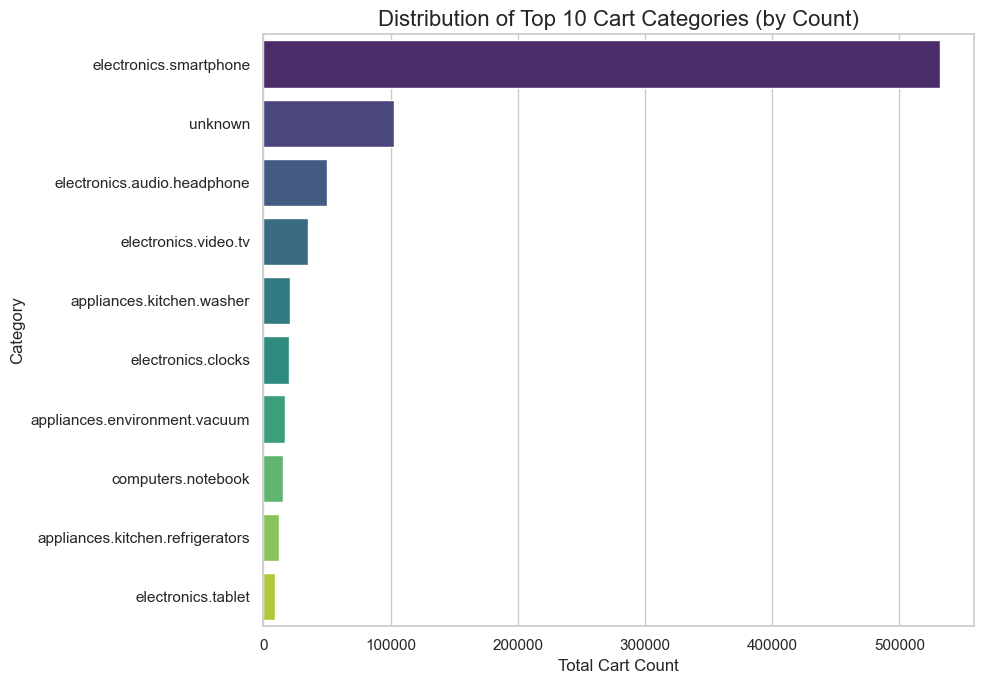


Generating pie chart...


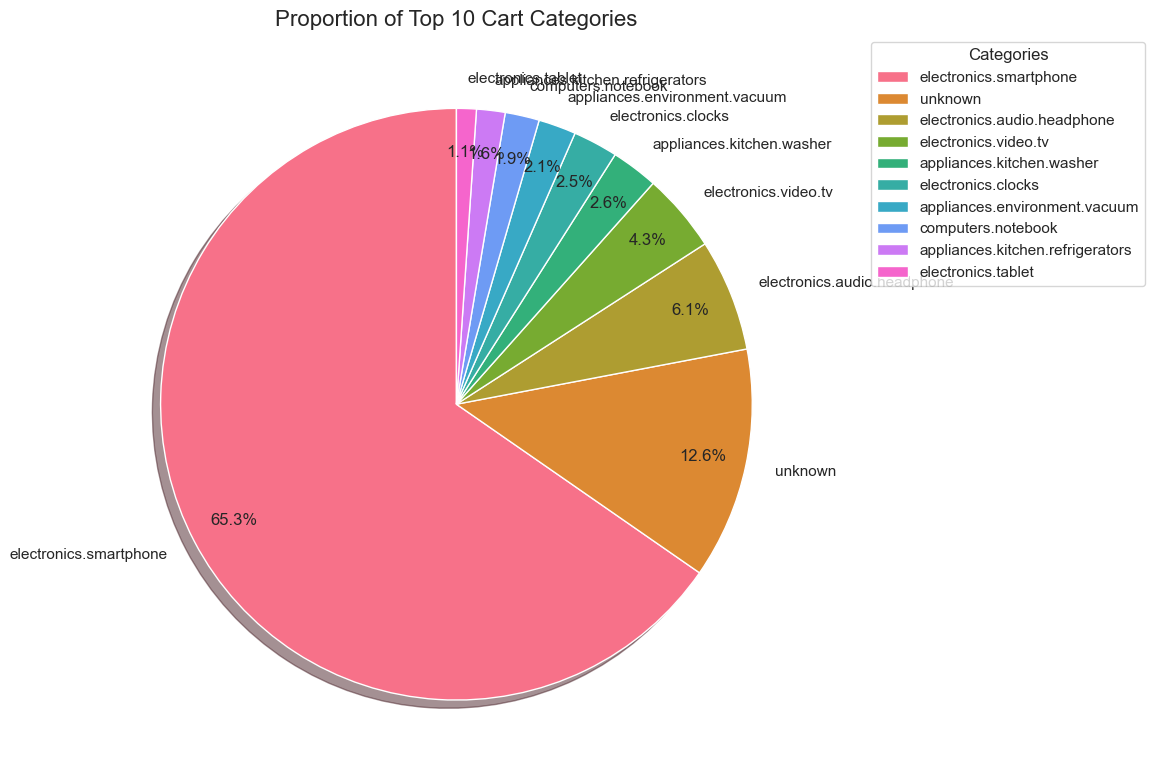

13389

In [48]:
FILE_NAME = '../ecommerce_oct/top10_categories_cart/csv/part-00000-bdab99bb-da02-4659-ae26-940b3a6c624e-c000.csv' 

data = pd.read_csv(FILE_NAME)

data = data.sort_values(by='count', ascending=False)

# Calculate percentage
data['percentage'] = (data['count'] / data['count'].sum())

# --- Show Statistics Table ---
print("\n--- Top 10 Cart Categories (Summary Table) ---")
styled_table = data.set_index('category_code').style.format({
    'count': '{:,.0f}',       # Format count with a comma
    'percentage': '{:.2%}'  # Format as percentage
})
display(styled_table) # Use display() for rich notebook output

print("\n--- Descriptive Statistics for 'count' ---")
count_stats = data['count'].describe()
print(count_stats)

# --- Draw Bar Chart ---
print("\nGenerating bar plot...")
plt.figure(figsize=(10, 7))

bars = sns.barplot(
    x='count',
    y='category_code',
    data=data,
    palette='viridis' 
)

# Update title and labels for "Cart"
plt.title('Distribution of Top 10 Cart Categories (by Count)', fontsize=16)
plt.xlabel('Total Cart Count', fontsize=12)
plt.ylabel('Category', fontsize=12)

plt.tight_layout()
plt.savefig('top10_cart_categories_bar.png') # New filename
plt.show()

# --- Draw Pie Chart ---
print("\nGenerating pie chart...")
plt.figure(figsize=(12, 8))

colors = sns.color_palette('husl', n_colors=len(data))

plt.pie(
    data['count'],
    labels=data['category_code'], # Set labels directly
    autopct='%.1f%%',
    startangle=90,
    colors=colors,
    pctdistance=0.85,
    shadow=True
)

plt.legend(
    labels=data['category_code'],
    title='Categories',
    bbox_to_anchor=(1.05, 1),
    loc='upper left'
)

# Update title for "Cart"
plt.title('Proportion of Top 10 Cart Categories', fontsize=16)

plt.tight_layout()
plt.savefig('top10_cart_categories_pie.png') # New filename
plt.show()

# --- Clean up memory ---
del data
del count_stats
del bars
plt.close('all')
gc.collect()


## Top 10 viewed categories analysis

,count,percentage
category_code,,
unknown,"13,198,871",41.92%
electronics.smartphone,"10,613,866",33.71%
electronics.clocks,"1,269,694",4.03%
computers.notebook,"1,104,738",3.51%
electronics.video.tv,"1,054,901",3.35%
electronics.audio.headphone,"1,017,621",3.23%
appliances.kitchen.refrigerators,"862,917",2.74%
appliances.kitchen.washer,"830,729",2.64%
appliances.environment.vacuum,"771,331",2.45%


count    1.000000e+01
mean     3.148230e+06
std      4.658749e+06
min      7.576350e+05
25%      8.387760e+05
50%      1.036261e+06
75%      1.228455e+06
max      1.319887e+07
Name: count, dtype: float64


/var/folders/_v/rp655h2s5z783x_7mbfhjbt40000gn/T/ipykernel_17725/1724141634.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  bars = sns.barplot(


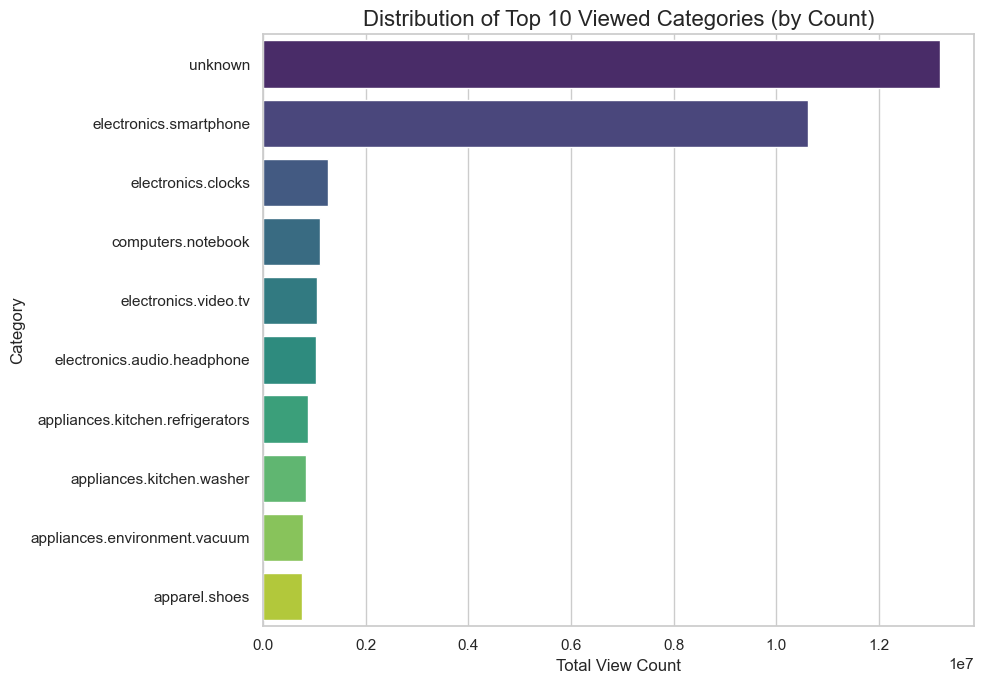

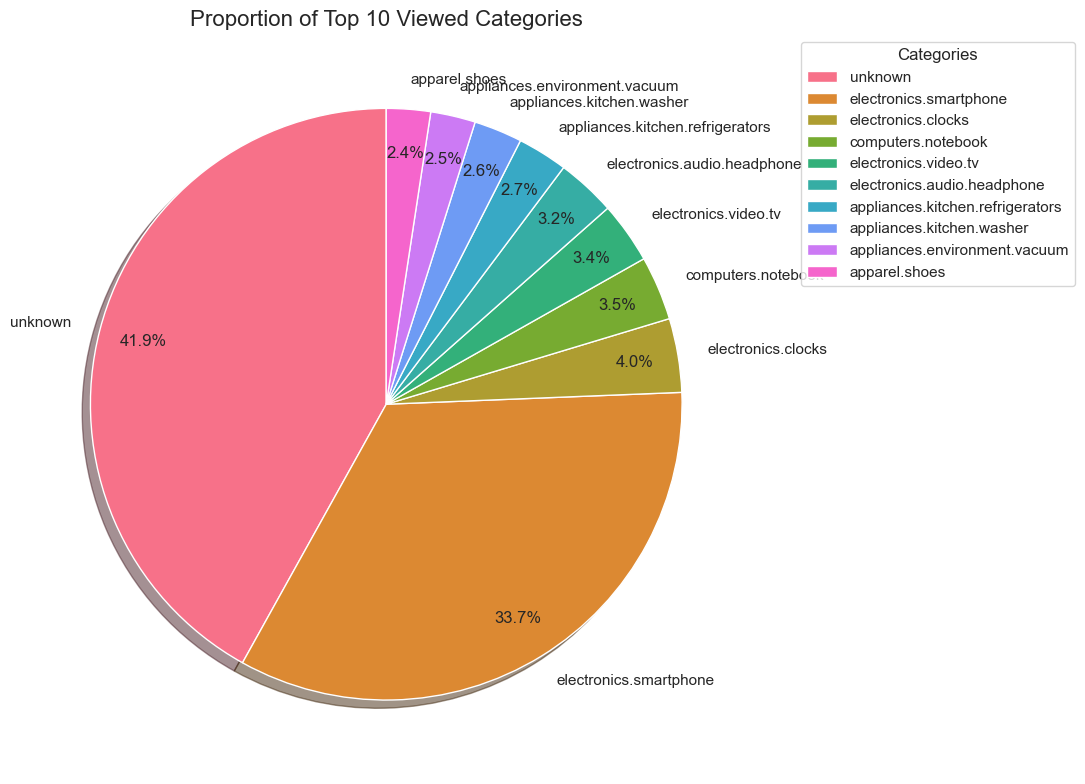

9064

In [49]:
FILE_NAME = '../ecommerce_oct/top10_categories_view/csv/part-00000-990d39f9-7eeb-4367-bffd-809d285754c6-c000.csv' 

data = pd.read_csv(FILE_NAME)

data = data.sort_values(by='count', ascending=False)

data['percentage'] = (data['count'] / data['count'].sum())

styled_table = data.set_index('category_code').style.format({
    'count': '{:,.0f}',       # Format count with a comma
    'percentage': '{:.2%}'  # Format as percentage
})
display(styled_table) 

count_stats = data['count'].describe()
print(count_stats)

plt.figure(figsize=(10, 7))

bars = sns.barplot(
    x='count',
    y='category_code',
    data=data,
    palette='viridis' 
)

# Update title and labels for "Viewed"
plt.title('Distribution of Top 10 Viewed Categories (by Count)', fontsize=16)
plt.xlabel('Total View Count', fontsize=12)
plt.ylabel('Category', fontsize=12)

plt.tight_layout()
plt.savefig('top10_viewed_categories_bar.png') # New filename
plt.show()

# --- Draw Pie Chart ---
plt.figure(figsize=(12, 8))

colors = sns.color_palette('husl', n_colors=len(data))

plt.pie(
    data['count'],
    labels=data['category_code'], # Set labels directly
    autopct='%.1f%%',
    startangle=90,
    colors=colors,
    pctdistance=0.85,
    shadow=True
)

plt.legend(
    labels=data['category_code'],
    title='Categories',
    bbox_to_anchor=(1.05, 1),
    loc='upper left'
)

# Update title for "Viewed"
plt.title('Proportion of Top 10 Viewed Categories', fontsize=16)

plt.tight_layout()
plt.savefig('top10_viewed_categories_pie.png') # New filename
plt.show()

# --- Clean up memory ---
del data
del count_stats
del bars
plt.close('all')
gc.collect()
